[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/allegheny-college-cmpsc-105-spring-2026/activity11_statsInferential_starter/blob/main/src/stats_inferential_activity.ipynb)

For a normal distribution, what is the probability of selecting a z-score that is larger than than $z = 1.96$?

In [93]:
import scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import pd, np, and matplotlib libraries

In [94]:
# write down the mean of a standard normal distribution
mean = 0
# write down the std of a standard normal distribution
std = 1

# use a function out of numpy called random.normal, passing in the mean, std, and how many samples to draw
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html
data = np.random.normal(mean,std,1000)

# convert to dataframe
df = pd.DataFrame(data, columns = ["values"])

df.head()

,values
0,0.378093
1,-0.416886
2,-0.287497
3,-2.144967
4,1.257966


In [95]:
# sanity check the mean
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html
df.mean()

,0
values,-0.00487


In [96]:
# sanity check the standard deviation
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.std.html
df.std()

,0
values,0.974237


In [97]:
# use scipy stats library to call a function called percentileofscore
# this function operates on data frames
# it finds the quantile of the specified z-value with tow parameters, the df and z-value
from scipy import stats

z_value = 1.96 # for 2 standard deviations (2.5% each side)

percentile = stats.percentileofscore(df["values"], z_value)

print("percentile:", percentile)

percentile: 97.60000000000001


In [98]:
# Sanity check by re-computing the z for a given proportion
# Use the numpy quantile function to pass in a particular quantile (or area) for
# which we would like to know the z score boundary
# https://numpy.org/doc/stable/reference/generated/numpy.quantile.html
# parameters are the data and the quantile

quantile = np.quantile(df["values"], percentile/100)

print("Estimated Z-Score:", quantile)

# what is the difference between quantile and percentile?
# Percentile is 0 to 1, while quantile is 0 to 100

Estimated Z-Score: 1.9325907006839025


In [99]:
# redefine the quantile in terms of an alpha/2

alpha = 0.05
quantile_value = 1-alpha/2
z_estimate = np.quantile(df["values"], quantile_value)
print("Quantile(1-alpha/2)", quantile_value)
print("Estimated Z-Score", z_estimate)

Quantile(1-alpha/2) 0.975
Estimated Z-Score 1.9233377876898092


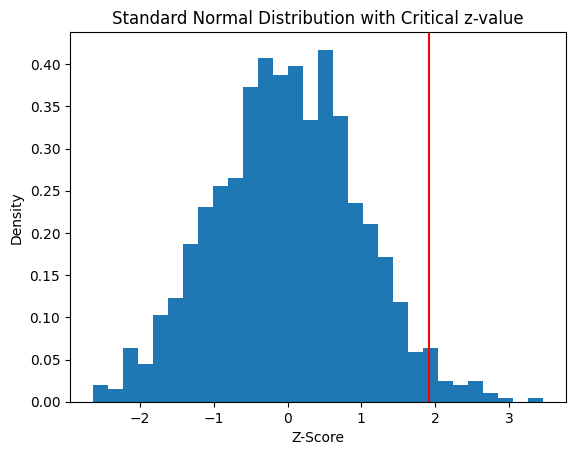

In [103]:
# plot the random normal data!
# the density parameter will normalize the y axis

plt.hist(df["values"], bins=30, density=True)
plt.axvline(x=z_estimate, color="red")
plt.title("Standard Normal Distribution with Critical z-value")
plt.xlabel("Z-Score")
plt.ylabel("Density")
plt.show()

# add a vertical line on your figure to mark the critical z-value

Work through this problem and verify everything in code. (Gravetter & Wallnau, Example 7.3)

> Once again, the distribution of SAT scores forms a normal distribution with a mean
of $\mu = 500$ and SEM = 20. For this example, we are going to
determine what kind of sample mean is likely to be obtained as the average SAT score
for a random sample of N = 25 students ($\sigma = 100$). Specifically, we determine the exact range of
values that is expected for the sample mean 80% of the time.
Our goal is to find the range of values that make
up the middle 80% of the distribution. Because the distribution is normal, we can use
the unit normal table. First, the 80% in the middle is split in half, with 40% (0.4000)
on each side of the mean. Looking up 0.4000 in column D (the proportion between the
mean and z), we find a corresponding z-score of z = 1.28. Thus, the z-score boundaries for the middle 80% are z = $\pm 1.28$. By definition, a z-score of 1.28
represents a location that is 1.28 standard deviations (or standard errors) from the
mean. With a standard error of 20 points, the distance from the mean is 1.28 * (20) = 25.6 points. The mean is $\mu = 500$, so a distance of 25.6 in both directions produces a
range of values from 474.4 to 525.6.
Thus, 80% of all the possible sample means are contained in a range between 474.4 and 525.6. If we select a sample of N = 25 students, we can be 80% confident that the
mean SAT score for the sample will be in this range.

In [120]:
# given values
mu = 500
sem = 20
middle_area = 0.80

# tail areas
alpha = 1 - middle_area
tail_area = alpha / 2

# z boundaries
z_upper = stats.norm.ppf(1 - tail_area)
z_lower = stats.norm.ppf(tail_area)

# convert z boundaries to raw sample-mean boundaries
x_lower = mu + z_lower * sem
x_upper = mu + z_upper * sem

print("alpha =", alpha)
print("tail area =", tail_area)
print("z lower =", z_lower)
print("z upper =", z_upper)
print("lower bound =", x_lower)
print("upper bound =", x_upper)

alpha = 0.19999999999999996
tail area = 0.09999999999999998
z lower = -1.2815515655446004
z upper = 1.2815515655446004
lower bound = 474.368968689108
upper bound = 525.631031310892
